In [1]:
%matplotlib widget

In [ ]:
import museval
from museval import iris_utils
from irispy.io import read_files
import json
from astropy import units as u
from astropy.coordinates import SkyCoord, SpectralCoord
from astropy.modeling import models as m
from astropy.modeling.fitting import LMLSQFitter, LevMarLSQFitter, TRFLSQFitter, parallel_fit_dask
from dask.distributed import Client
import matplotlib.pyplot as plt
import numpy as np
from irispy.spectrograph import SpectrogramCube
import warnings

In [ ]:
obs_data_dir = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/AR_datasets/'
target_url = 'https://www.lmsal.com/hek/hcr?cmd=search-events3&outputformat=json&startTime=2020-12-27T16:00&stopTime=2020-12-27T18:00&hasData=true&hideMostLimbScans=true&obsDesc=12795&limit=200'
downloaded_filename=iris_utils.download_hek_json(target_url, obs_data_dir)

In [ ]:
with open(downloaded_filename, "r") as f:
    data = json.load(f)

target_url = iris_utils.find_iris_raster_url(data, min_exptime=4)
raster_filename = iris_utils.download_iris_raster(target_url, obs_data_dir)

In [4]:
raster = read_files(raster_filename, memmap=False)
raster


Raster Collection
-----------------
Spectral Windows (cube keys): (np.str_('C II 1336'), np.str_('Si IV 1394'), np.str_('Mg II k 2796'))
Number of Cubes: 3
Aligned dimensions: [1 320 548]
Aligned physical types: [('meta.obs.sequence',), ('custom:pos.helioprojective.lat', 'custom:pos.helioprojective.lon', 'time'), ('custom:pos.helioprojective.lat', 'custom:pos.helioprojective.lon')]

In [5]:
raster.keys()
si_iv_1394 = raster['Si IV 1394'][0]
si_iv_1394_core = 139.375 * u.nm
lower_corner = [SpectralCoord(si_iv_1394_core), None]
upper_corner = [SpectralCoord(si_iv_1394_core), None]
si_iv_spec_crop = si_iv_1394.crop(lower_corner, upper_corner)

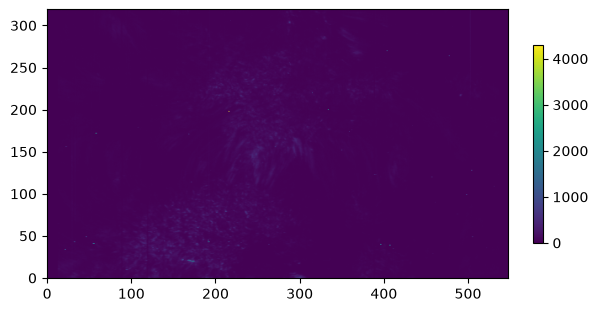

In [6]:
plt.figure()
plt.imshow(si_iv_spec_crop.data,vmin=0,cmap='viridis', origin='lower')
plt.colorbar(fraction=0.02)
plt.show()

In [8]:
normalized_unit = si_iv_1394.unit / u.s
exposure_time_reshaped = si_iv_1394.exposure_time.value[:, np.newaxis, np.newaxis]
normalized_data = si_iv_1394.data/ exposure_time_reshaped
normalized_data = np.where(np.isnan(normalized_data), 0, normalized_data) # can be nan because of the zero exposure time
normalized_si_iv_spec = SpectrogramCube(
                    normalized_data,
                    si_iv_1394.wcs,
                    meta=si_iv_1394.meta,
                    unit=normalized_unit,
                    uncertainty=si_iv_1394.uncertainty,
                    copy=True,
                )
wl_sum = normalized_si_iv_spec.rebin((1, 1, normalized_si_iv_spec.data.shape[-1]), operation=np.sum)[0]
spatial_mean = normalized_si_iv_spec.rebin((*normalized_si_iv_spec.data.shape[:-1], 1))[0, 0, :]
initial_model = m.Const1D(amplitude=1/si_iv_1394.exposure_time.value[0] * normalized_si_iv_spec.unit) + m.Gaussian1D(
                    amplitude=np.nanmax(spatial_mean.data) * normalized_si_iv_spec.unit, mean=si_iv_1394_core, stddev=0.005 * u.nm
                )
wavelength_coords = spatial_mean.axis_world_coords("em.wl")[0].to(u.nm)
fitter = TRFLSQFitter() #LevMarLSQFitter(): apparently it is a legacy fitter and not recommended for new code. Use LMLSQFitter() instead.
average_fit = fitter(
                    initial_model,
                    wavelength_coords,
                    # spatial_mean.axis_world_coords("em.wl")[0].to(u.nm),
                    spatial_mean.data * spatial_mean.unit,
                    filter_non_finite = True,  # Allow fitting with non-finite values
                )
filtered_data = np.where(normalized_si_iv_spec.data < 0, 0, normalized_si_iv_spec.data)
filtered_data = np.where(np.isfinite(filtered_data), filtered_data, 0)

In [9]:
filtered_data.min(), filtered_data.max()

(np.float64(0.0), np.float64(2022.9749998658747))

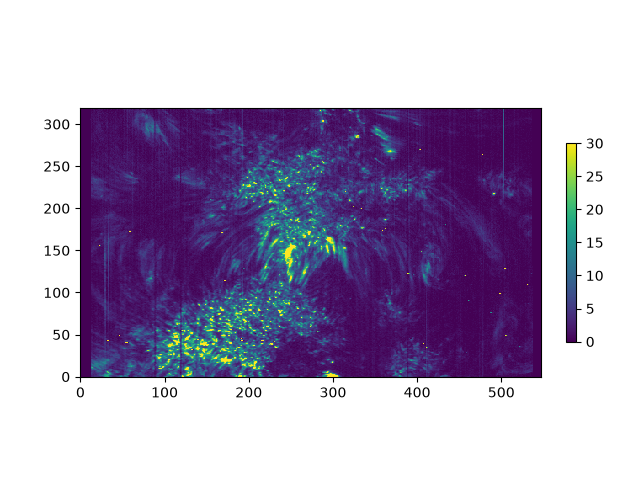

In [10]:
plt.figure()
plt.imshow(normalized_si_iv_spec.crop(lower_corner, upper_corner).data, vmin=0, vmax=30,cmap='viridis', origin='lower',
           interpolation='none')
plt.colorbar(fraction=0.02)
plt.show()

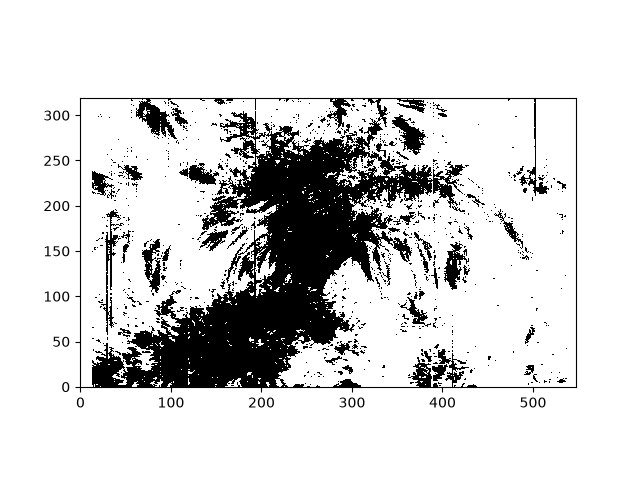

In [26]:
fit_mask = np.where(normalized_si_iv_spec.crop(lower_corner, upper_corner).data >= np.nanpercentile(normalized_si_iv_spec.crop(lower_corner, upper_corner).data.flatten(), 68), 1, np.nan)
# fit_mask1 = fit_mask[:,:,np.newaxis]
plt.figure()
plt.imshow(fit_mask, origin='lower',cmap='gray', interpolation='none')
plt.show()

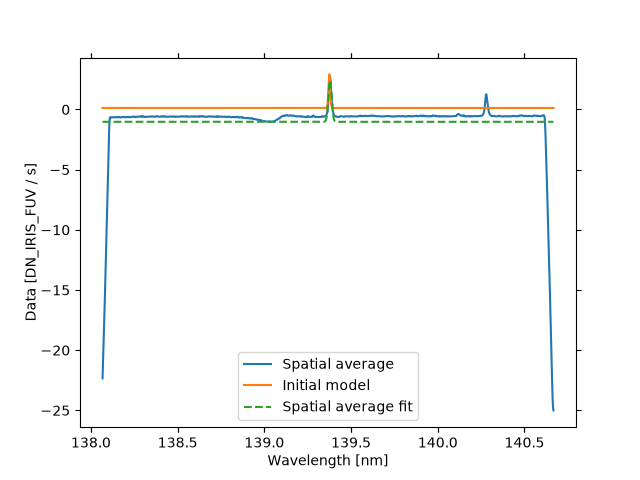

In [11]:
wavelength_coords = spatial_mean.axis_world_coords("em.wl")[0].to(u.nm)
fig = plt.figure()
ax = spatial_mean.plot(label="Spatial average")
ax.plot(initial_model(wavelength_coords), label="Initial model")
ax.plot(average_fit(wavelength_coords), linestyle="--", label="Spatial average fit")
plt.legend()
plt.show()
# ax.set_xlim([wavelength_coords[10].value, wavelength_coords[-15].value])

In [12]:
client = Client(n_workers=10, threads_per_worker=1, memory_limit="8GB", dashboard_address=None)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fitted_params = parallel_fit_dask(data=filtered_data,
                                      data_unit=normalized_si_iv_spec.unit,
                                      model=average_fit,
                                      fitting_axes=2,
                                    #   mask=fit_mask1,
                                      world= (wavelength_coords,),
                                      fitter=fitter,
                                      scheduler=client,
    )


In [17]:
import astropy.constants as constants
net_flux = (
    np.sqrt(2 * np.pi)
    * (fitted_params.amplitude_0 + fitted_params.amplitude_1)
    * fitted_params.stddev_1.quantity
    / np.mean(si_iv_1394.axis_world_coords("wl")[0][1:] - si_iv_1394.axis_world_coords("wl")[0][:-1]).to(u.nm)
)

core_shift = ((fitted_params.mean_1.quantity.to(u.nm)) - si_iv_1394_core) / si_iv_1394_core * (constants.c.to(u.km / u.s))
sigma = (fitted_params.stddev_1.quantity.to(u.nm)) / si_iv_1394_core * (constants.c.to(u.km / u.s))

NameError: name 'net_flux' is not defined

<Figure size 640x480 with 0 Axes>

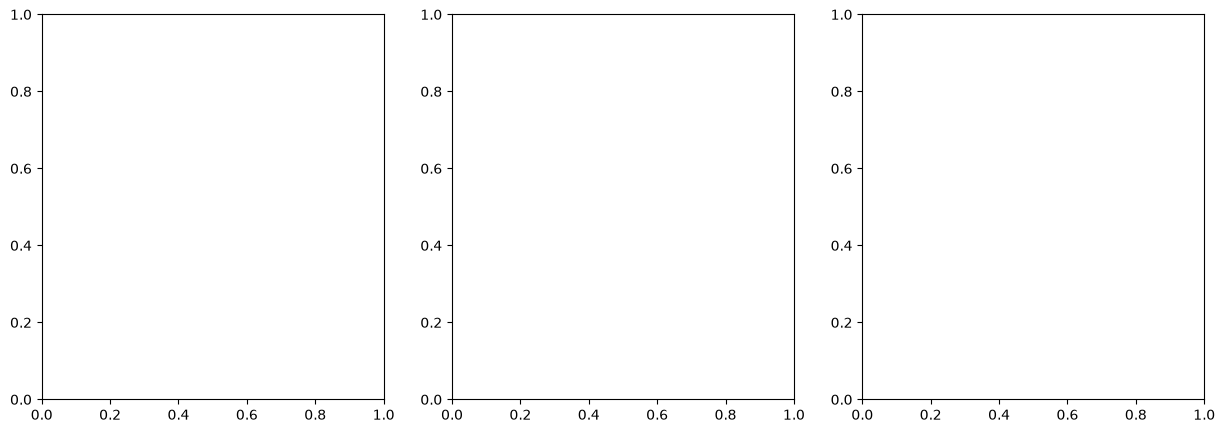

In [36]:
plt.close('all')
plt.figure()
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(net_flux.data, cmap='bone_r', origin='lower', vmin=0, vmax=120, interpolation='none')
ax[0].set_title('Net Flux')
ax[1].imshow(core_shift.data*fit_mask, cmap='coolwarm', origin='lower',vmax=15, vmin=-15, interpolation='none')
ax[1].set_title('Core Shift')
ax[2].imshow(sigma.data*fit_mask, cmap='plasma', origin='lower',vmin=0, vmax=25, interpolation='none')
ax[2].set_title('Sigma')
# plt.show()

In [ ]:
if __name__ == "__main__":
    client = Client(n_workers=10, threads_per_worker=1, memory_limit="8GB", dashboard_address=None)
    iris_model_fit, si_iv_1394 = iris_utils.fit_si_iv(raster, client)
    client.close()

In [ ]:
date_begin = raster['Si IV 1394'].meta['Date_Obs'].split('T')[0]
iris_utils.save_fit_results(iris_model_fit, si_iv_1394, date_begin, obs_data_dir)

In [18]:
import numpy as np
import matplotlib.pyplot as plt

save_path = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/AR_datasets/'
fitted_params = np.load(save_path+'iris_fit_results_1394_2020-12-27.npz', allow_pickle=True)


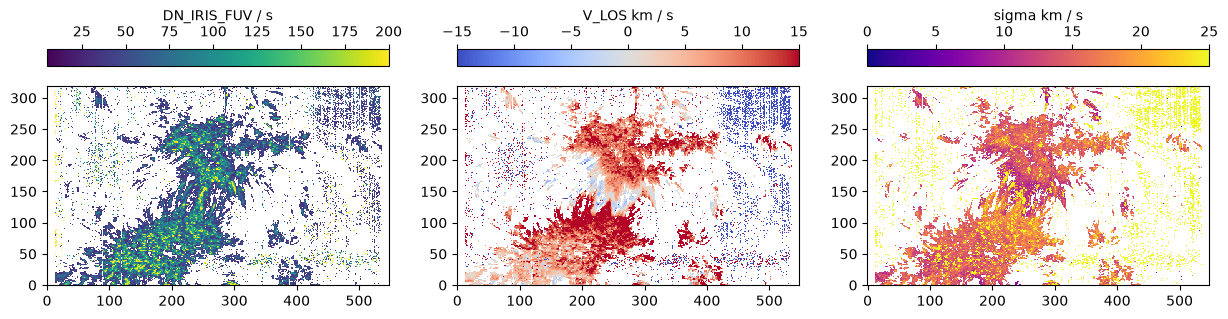

In [48]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
ax = ax.ravel()
im=ax[0].imshow(fitted_params['net_flux']*mask, cmap='viridis', origin='lower',vmax=200, vmin=5, interpolation='none')
plt.colorbar(im, location='top', label=fitted_params['net_flux_unit'])
im = ax[1].imshow(fitted_params['core_shift']*mask, cmap='coolwarm', origin='lower',vmax=15, vmin=-15, interpolation='none')
plt.colorbar(im, location='top', label='V_LOS'+' ' +fitted_params['core_shift_unit'])
im =ax[2].imshow(fitted_params['sigma']*mask,cmap='plasma', origin='lower',vmin=0, vmax=25, interpolation='none')
plt.colorbar(im, location='top', label='sigma '+fitted_params['sigma_unit'])


(array([20048., 21430., 20232., 16545., 12833.,  9889.,  7876.,  6379.,
         5310.,  4553.,  4056.,  3606.,  3041.,  2663.,  2401.,  2156.,
         1884.,  1731.,  1570.,  1409.,  1314.,  1173.,  1118.,  1024.,
         1000.,   891.,   788.,   743.,   660.,   615.,   535.,   529.,
          464.,   423.,   339.,   357.,   318.,   256.,   243.,   241.,
          218.,   222.,   190.,   172.,   130.,   162.,   127.,   113.,
          103.,    88.]),
 array([  0.,   4.,   8.,  12.,  16.,  20.,  24.,  28.,  32.,  36.,  40.,
         44.,  48.,  52.,  56.,  60.,  64.,  68.,  72.,  76.,  80.,  84.,
         88.,  92.,  96., 100., 104., 108., 112., 116., 120., 124., 128.,
        132., 136., 140., 144., 148., 152., 156., 160., 164., 168., 172.,
        176., 180., 184., 188., 192., 196., 200.]),
 <BarContainer object of 50 artists>)

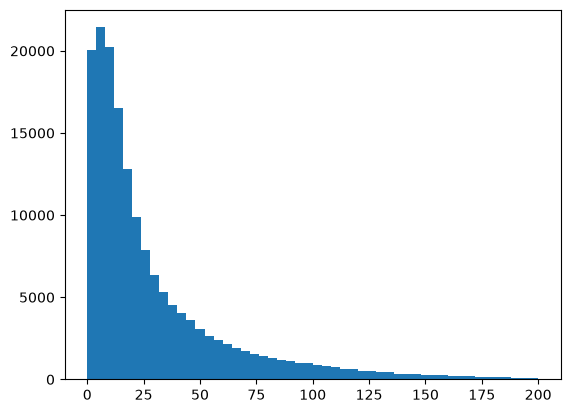

In [42]:
hist_data = fitted_params['net_flux'].flatten()
plt.hist(hist_data, bins=50, range=(0,200))

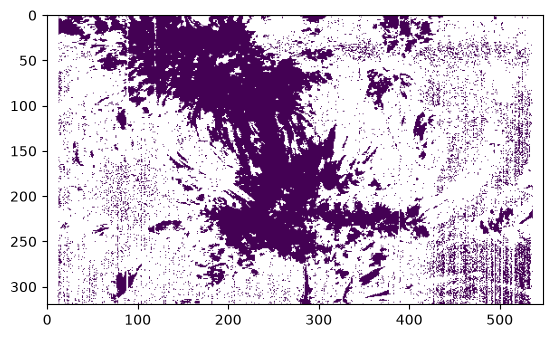

In [43]:
mask  = np.where(fitted_params['net_flux'] >= np.nanpercentile(hist_data, 68), 1, np.nan)
plt.imshow(mask)